## import pandas and numpy and matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:\\Users\\Azhagiri\\OneDrive\\Desktop\\Chennai dataset\\Chennai_Data\\Chennai.csv")

In [3]:
df.head()

,Accident_ID,Area,Date,Time,Vehicle_Type,Driver_Age,Cause,Injuries,Deaths,Weather
0,1009,t nagar,2022-01-27 00:00:00,21:41,Bike,60.0,Drunk Driving,3,1,Clear
1,1015,Anna Nagar,2024-06-03 00:00:00,2:59,bus,60.0,Drunk Driving,5,1,RAINY
2,1064,NaN,03-03-2024,3:8,Auto,NaN,Signal Jump,0,1,Cloudy
3,1028,Porur,2024-05-26 00:00:00,4:2,Bus,30.0,NaN,1,2,NaN
4,1089,t nagar,2024-04-27 00:00:00,3:60,NaN,17.0,overspeed,3,2,NaN


In [4]:
df.shape

(1400, 10)

In [5]:
df=df.drop_duplicates()
df=df.dropna()


In [6]:
df.isnull().sum()

Accident_ID     0
Area            0
Date            0
Time            0
Vehicle_Type    0
Driver_Age      0
Cause           0
Injuries        0
Deaths          0
Weather         0
dtype: int64

In [7]:
df["Area"].unique()

array(['t nagar', '   Anna Nagar', 'T Nagar', 'Guindy', 'Chromepet',
       'Adyar', 'Velachery', 'OMR', 'Perungudi', 'VELACHERY', 'Porur',
       'guindy', 'Tambaram', 'Anna Nagar'], dtype=object)

In [8]:
df[["Area" , "Vehicle_Type" , "Cause" , "Weather"]] = df[["Area" , "Vehicle_Type" , "Cause" , "Weather"]].apply(lambda x : x.str.strip())

In [9]:
df["Area"] = df["Area"].str.lower()
df["Area"] =df["Area"].str.title()
df["Vehicle_Type"] = df["Vehicle_Type"].str.lower()
df["Vehicle_Type"] = df["Vehicle_Type"].str.title()
df["Cause"] = df["Cause"].str.lower()
df["Weather"] = df["Weather"].str.title()

In [10]:
df.shape

(304, 10)

In [11]:
df["Date"] =pd.to_datetime(df["Date"],errors="coerce")

In [12]:
df=df[df["Time"].str.split(":").str[1].astype(int)<60]

In [13]:
df=df[df["Time"].str.split(":").str[0].astype(int)<24]

In [14]:
df["Time"] =pd.to_datetime(df["Time"],errors="coerce").dt.time

C:\Users\Azhagiri\AppData\Local\Temp\ipykernel_18472\1234079829.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] =pd.to_datetime(df["Time"],errors="coerce").dt.time


In [15]:
df=df[df["Driver_Age"]<100]

In [16]:
df[["Injuries" , "Deaths"]] = df[["Injuries" , "Deaths"]].clip(lower=0)

In [17]:
df.shape

(196, 10)

In [18]:
df=df.dropna(subset=["Date" , "Time"])

In [19]:
df.shape

(146, 10)

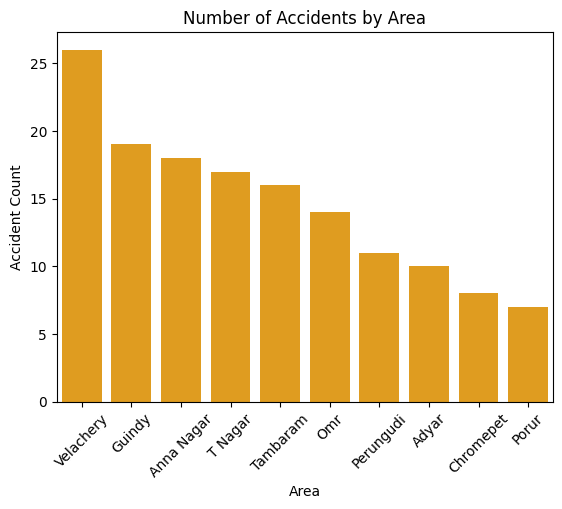

In [20]:
plt.Figure(figsize=(12, 6))
sns.countplot(data=df , x="Area" , order=df["Area"].value_counts().index ,color="Orange")
plt.xticks(rotation =45)
plt.title("Number of Accidents by Area")
plt.ylabel("Accident Count")
plt.show()

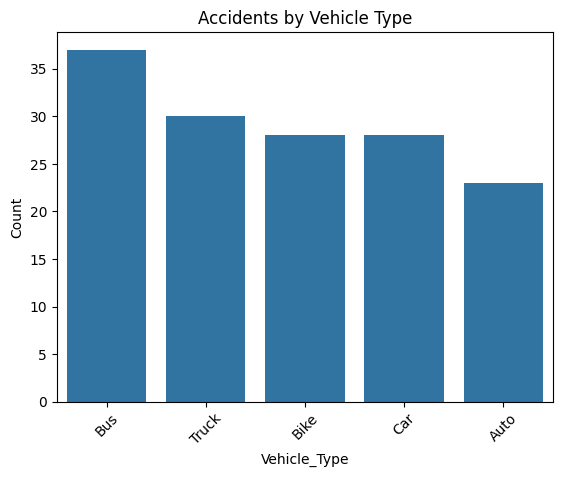

In [21]:
plt.Figure(figsize=(12,6))
sns.countplot(data=df , x="Vehicle_Type" , order=df["Vehicle_Type"].value_counts().index)
plt.xticks(rotation =45)
plt.title("Accidents by Vehicle Type")
plt.ylabel("Count")
plt.show()

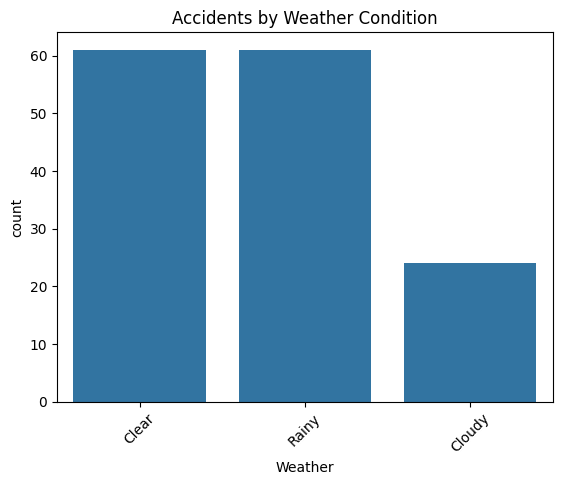

In [22]:
plt.Figure(figsize=(12,6))
sns.countplot(data=df , x="Weather")
plt.xticks(rotation =45)
plt.title("Accidents by Weather Condition")
plt.show()

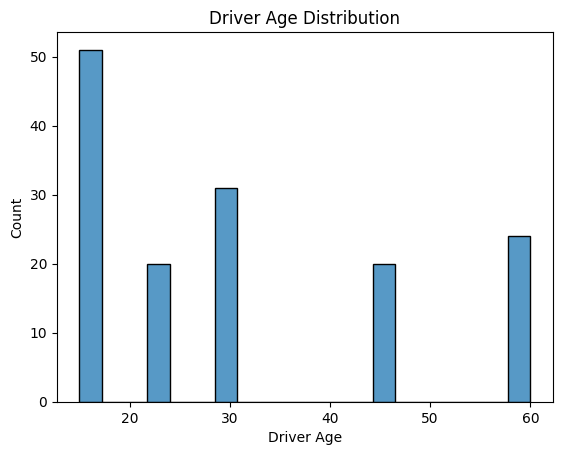

In [23]:
plt.Figure(figsize=(6,4))
sns.histplot(df["Driver_Age"].sort_values(), bins=20)
plt.title("Driver Age Distribution")
plt.xlabel("Driver Age")
plt.show()

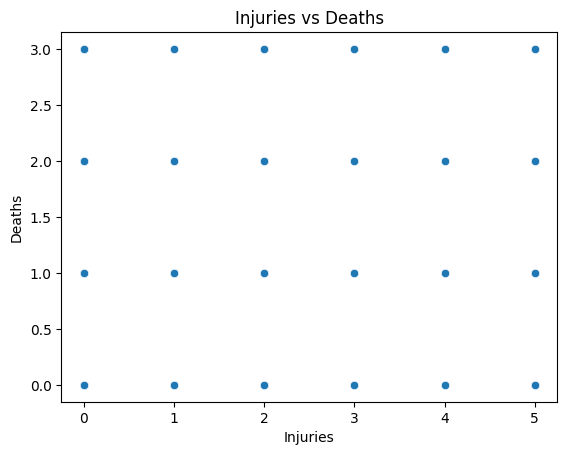

In [24]:
plt.Figure(figsize=(6,4))
sns.scatterplot(x=df["Injuries"], y=df["Deaths"])
plt.xlabel("Injuries")
plt.ylabel("Deaths")
plt.title("Injuries vs Deaths")
plt.show()

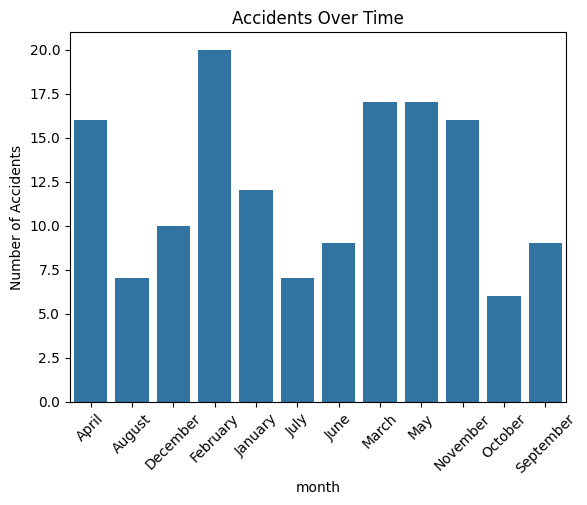

In [25]:
df["Month"] = df["Date"].dt.month_name()
accidents_per_month =df.groupby("Month").size()

plt.Figure(figsize=(12,6))
sns.barplot(x=accidents_per_month.index, y=accidents_per_month.values)
plt.xticks(rotation=45)
plt.title("Accidents Over Time")
plt.xlabel("month")
plt.ylabel("Number of Accidents")
plt.show()
           